## EDA (Exploratory Data Analysis)

In [1]:
import json

import pandas as pd
import random
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.font_manager import json_dump

RANDOM_STATE = 333093
random.seed(RANDOM_STATE)

In [2]:
X = pd.read_csv('../data/artifical_train_data.csv')
y = pd.read_csv('../data/artifical_train_labels.csv')
y = y.Class
df = pd.concat([X, y], axis=1)

Wymiary:

In [3]:
print(f'X_train: {X.shape}\n'
      f'Y_train {y.shape}')

X_train: (1500, 100)
Y_train (1500,)


#### 1. Missing values

In [4]:
df.shape

(1500, 101)

In [5]:
df.dropna().shape

(1500, 101)

#### 2. Is data transformation needed?

In [6]:
skews = X.skew()
skews_top10 = skews.sort_values(ascending=True)
skews_button10 = skews.sort_values(ascending=False)
print('TOP10 -------------------------- BUTTON10')
for i in range(5):
    print(skews_top10.iloc[i], '--------', skews_button10.iloc[i])

TOP10 -------------------------- BUTTON10
-0.1733562472838124 -------- 0.15756049299427743
-0.14198950825022638 -------- 0.14822909868725057
-0.11163744894772133 -------- 0.1439999130941208
-0.10381112084133888 -------- 0.13367653455024361
-0.08711332080103057 -------- 0.1254365648598854


As we can see there are no variables that are strongly skewed, so data transformation is not really needed.

#### 3. Class imbalance.

In [12]:
class1 = y.loc[y == 1].size / y.shape[0]
class2 = 1 - class1
print(f'Class1 [percentage]: {class1:.3f}')
print(f'Class2 [percentage]: {class2:.3f}')

Class1 [percentage]: 0.503
Class2 [percentage]: 0.497


Classes are perfectly balanced.

#### 4. Dimensionality reduction

##### Splitting data into train/test sets:

In [8]:
from src.utils.data import split_data, save_train_data, save_test_data
X_train, X_val, y_train, y_val = split_data(X, y)
save_train_data(X_train, y_train)
save_test_data(X_val, y_val)

##### Importing necessary tools:

In [13]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier

Are there any variables with low variance?

In [10]:
threshold_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('sel_var', VarianceThreshold(threshold=0.1))
])
threshold_pipeline.fit(X_train)
X_scaled = threshold_pipeline.transform(X_train)

In [11]:
X_scaled.shape

(1200, 100)

No such variables.

#### 5. Is the data more or less linear or not?

We are going to test several models in the upcoming parts of the project, so first we are going to check what type of models perform better on the given data: linear or non-linear?

1. Linear models (Logistic Regression, SVM)

In [14]:
grid_par = {'reg__l1_ratio': [1,0,0.5],
            'reg__solver': ['saga']}

reg_pipeline = Pipeline([
    ('sca', StandardScaler()),
    ('reg', LogisticRegression(max_iter=5_000))
]
)
grid_search = GridSearchCV(
    estimator=reg_pipeline,
    param_grid=grid_par,
    n_jobs=-1,
    cv=10,
    scoring='roc_auc'
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=5000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'reg__l1_ratio': [1, 0, ...], 'reg__solver': ['saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >

In [15]:
grid_search.best_score_

np.float64(0.6208150103423791)

In [16]:
svm_pipeline = Pipeline([
    ('sca', StandardScaler()),
    ('svm', SVC())
])
cross_val_score(estimator=svm_pipeline, cv=10, n_jobs=-1, X=X_train, y=y_train, scoring='roc_auc').mean()

np.float64(0.7294397054737427)

2. Non-linear models: KNN, RandomForest, ExtraTrees, GradientBoost

In [20]:
KNN_pipe = Pipeline([
    ('sca', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

KNN_score = cross_val_score(estimator=KNN_pipe, cv=10, n_jobs=-1, X=X_train, y=y_train, scoring='roc_auc').mean()

RF = RandomForestClassifier(random_state=RANDOM_STATE)
RF_score = cross_val_score(estimator=RF, cv=10, n_jobs=-1, X=X_train, y=y_train, scoring='roc_auc').mean()

ET = ExtraTreesClassifier(random_state=RANDOM_STATE)
ET_score = cross_val_score(estimator=ET, cv=10, n_jobs=-1, X=X_train, y=y_train, scoring='roc_auc').mean()

GB = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
GB_score = cross_val_score(estimator=GB, cv=10, n_jobs=-1, X=X_train, y=y_train, scoring='roc_auc').mean()

In [21]:
print(f'KNN: {KNN_score:.2f}')
print(f'GradBoost: {GB_score:.2f}')
print(f'RF: {RF_score:.2f}')
print(f'ET: {ET_score:.2f}')

KNN: 0.72
GradBoost: 0.85
RF: 0.85
ET: 0.86


We can clearly see that there is a significant difference in performance between these two groups of models. Now we are going to stick to non-linear models for the rest of the project.

#### Variables Selection

This is a crucial part of the project. Since there are many variables, we want to keep only those that truly matter. We will use the `permutation_importance` method.

Warning: this step can be time-consuming, so we set the `n_jobs` parameter to -1 to use all available CPU cores. Feel free to change this value if you are unsure how your computer will handle it.

In [22]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import KFold
from sklearn.base import clone

In [23]:
model = ExtraTreesClassifier(n_jobs=-1,
                             random_state=RANDOM_STATE,
                             n_estimators=500
                             )
cv = KFold(n_splits=10, random_state=RANDOM_STATE, shuffle=True)

importance_list = []

for fold, (train_index, val_index) in enumerate(cv.split(X_train, y_train)):

    X_fold_train = X_train.iloc[train_index]
    y_fold_train = y_train.iloc[train_index]

    X_fold_val = X_train.iloc[val_index]
    y_fold_val = y_train.iloc[val_index]

    model_fold = clone(model)
    model_fold.fit(X_fold_train, y_fold_train)

    pi = permutation_importance(
        estimator=model_fold,
        X=X_fold_val,
        y=y_fold_val,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        n_repeats=10,
        scoring='roc_auc'
    )

    importance_list.append(pi.importances_mean)

imp_mean = pd.Series(np.mean(importance_list, axis=0), index=X.columns).sort_values(ascending=False)
imp_std  = pd.Series(np.std(importance_list, axis=0),  index=X.columns)

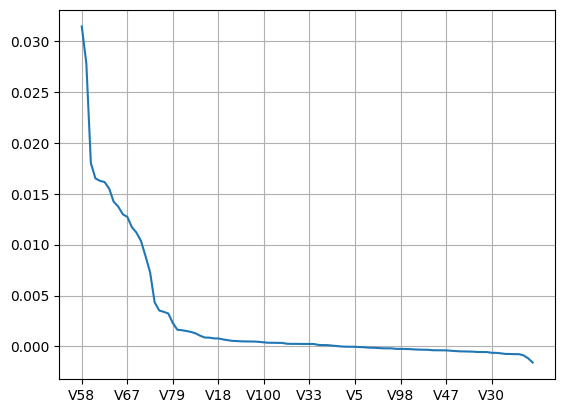

In [24]:
fig,ax = plt.subplots()
ax.plot(imp_mean)
ax.plot()
ax.set_xticks(range(0,len(imp_mean), 10))
ax.grid()

In [25]:
important_features = imp_mean.loc[imp_mean > 0]
if_number = important_features.count()

Can wee see an improvement with the results?

In [26]:
scores = []

KNN_pipe = Pipeline([
    ('sca', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

for i in range(1, if_number+1):

    selected_features = imp_mean.head(i).index

    X_train_selected = X_train[selected_features]

    KNN_score = cross_val_score(estimator=KNN_pipe, cv=10, n_jobs=-1, X=X_train_selected, y=y_train, scoring='roc_auc').mean()

    RF = RandomForestClassifier(random_state=RANDOM_STATE)
    RF_score = cross_val_score(estimator=RF, cv=10, n_jobs=-1, X=X_train_selected, y=y_train, scoring='roc_auc').mean()

    ET = ExtraTreesClassifier(random_state=RANDOM_STATE)
    ET_score = cross_val_score(estimator=ET, cv=10, n_jobs=-1, X=X_train_selected, y=y_train, scoring='roc_auc').mean()

    GB = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
    GB_score = cross_val_score(estimator=GB, cv=10, n_jobs=-1, X=X_train_selected, y=y_train, scoring='roc_auc').mean()

    scores.append({
        'KNN': KNN_score,
        'RF': RF_score,
        'ET': ET_score,
        'GB': GB_score
    })

In [27]:
scores = pd.DataFrame(scores)

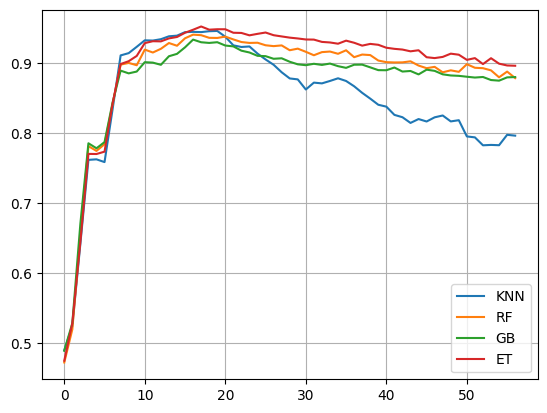

In [28]:
fig, ax = plt.subplots()
ax.plot(scores['KNN'], label='KNN')
ax.plot(scores['RF'], label='RF')
ax.plot(scores['GB'], label='GB')
ax.plot(scores['ET'], label='ET')
ax.grid()
ax.legend()

In [29]:
scores.loc[scores.KNN == scores.KNN.max()]

,KNN,RF,ET,GB
19,0.946245,0.936216,0.948676,0.930132


As we can clearly see all models achieve best results with 10-20 the best variables. Now for the rest of the project we are going to keep only these variables. With that we can end this part of the project.

In [30]:
important_features.head(20).index

Index(['V58', 'V10', 'V57', 'V51', 'V87', 'V90', 'V8', 'V50', 'V83', 'V43',
       'V67', 'V73', 'V42', 'V64', 'V22', 'V3', 'V9', 'V65', 'V91', 'V11'],
      dtype='object')

In [32]:
### now we will save selected variables:
import json

top_features = list(important_features.head(20).index)

with open('../artefacts/top_features.json', 'w', encoding='utf-8') as file:
    json.dump(top_features, file, ensure_ascii=False, indent=2)